# **Machine Learning project on the Iris dataset**

## MODULE 1

Shape: (150, 5)

--- Head ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Describe ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Columns ---
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicates: 3
Target column: species
species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64


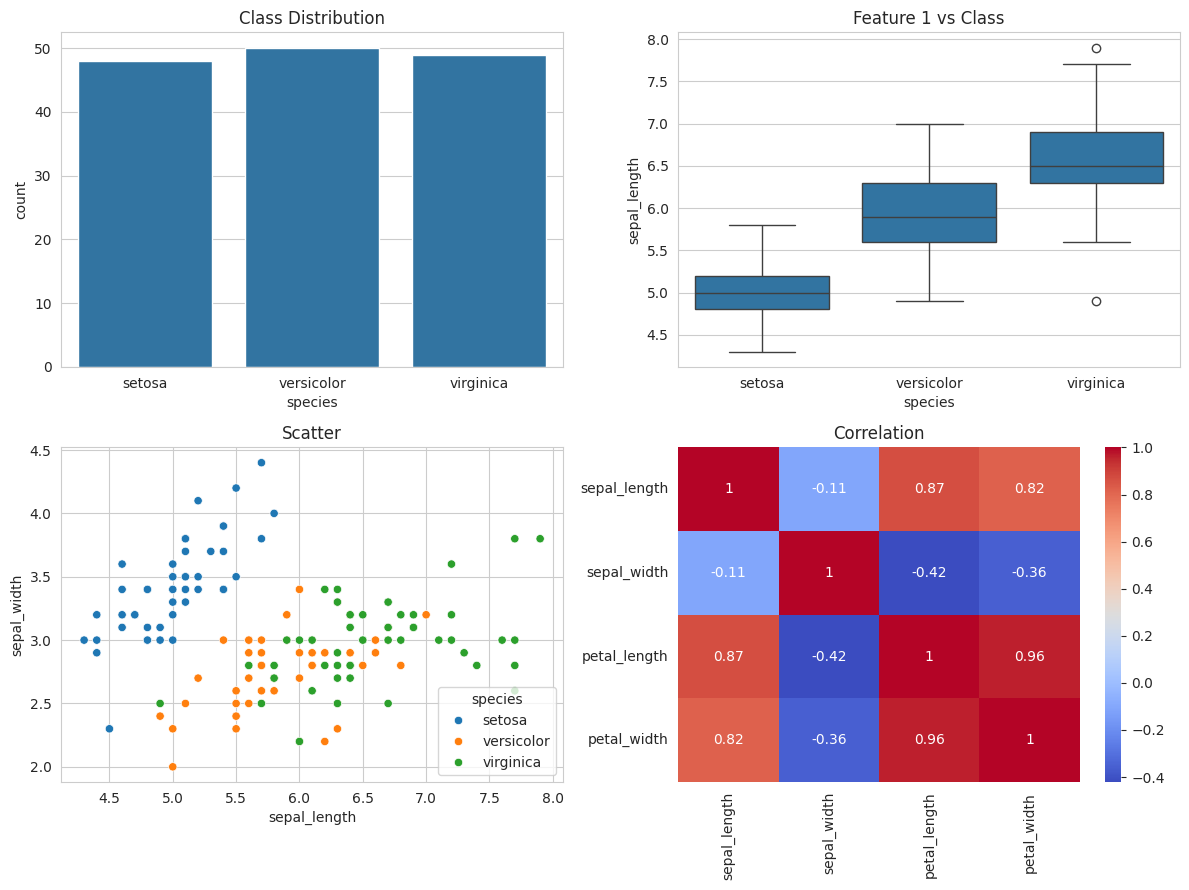

In [1]:
# ============================================
# Module 1.1 — Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)

sns.set_style("whitegrid")
RANDOM_STATE = 42

# ============================================
# Module 1.2 — Load Data
# ============================================
DATA_PATH = "/kaggle/input/datasets/anwarkhanniazi/supervised-learning-classification/iris.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)

# ============================================
# Module 1.3 — Dataset Overview
# ============================================
print("\n--- Head ---")
display(df.head())

print("\n--- Info ---")
df.info()

print("\n--- Describe ---")
display(df.describe())

print("\n--- Columns ---")
print(df.columns.tolist())

# ============================================
# Module 1.4 — Missing Values
# ============================================
print("\nMissing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# ============================================
# Module 1.5 — Target Analysis
# ============================================
# Auto-detect target column (usually 'species' or 'Species' or last col)
target_col = [c for c in df.columns if df[c].dtype == 'object' or df[c].nunique() <= 5][-1]
print("Target column:", target_col)
print(df[target_col].value_counts())

# ============================================
# Module 1.6 — EDA Plots
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.countplot(x=target_col, data=df, ax=axes[0,0]); axes[0,0].set_title("Class Distribution")
sns.boxplot(data=df, x=target_col, y=df.columns[0], ax=axes[0,1]); axes[0,1].set_title("Feature 1 vs Class")
sns.scatterplot(data=df, x=df.columns[0], y=df.columns[1], hue=target_col, ax=axes[1,0]); axes[1,0].set_title("Scatter")
sns.heatmap(df.drop(columns=[target_col]).corr(), annot=True, cmap="coolwarm", ax=axes[1,1]); axes[1,1].set_title("Correlation")
plt.tight_layout(); plt.show()

## Module 2 — Feature Processing

Classes: ['setosa' 'versicolor' 'virginica']


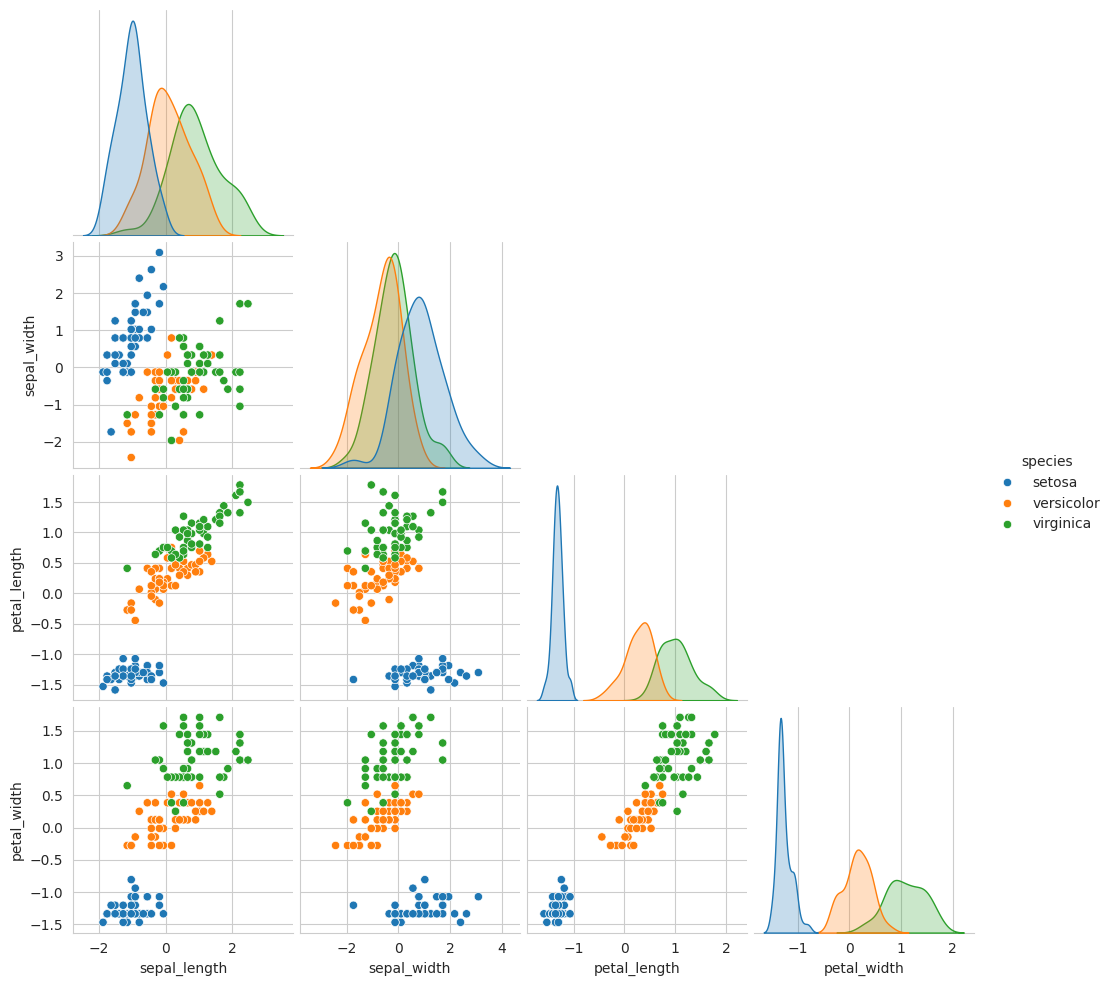

In [2]:
# ============================================
# Module 2.1 / 2.2 / 2.3 — Feature Engineering
# ============================================
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target if string
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)

# Scale features (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================
# Module 2.4 — Visualization after scaling
# ============================================
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df[target_col] = y.values
sns.pairplot(X_scaled_df, hue=target_col, corner=True, diag_kind="kde")
plt.show()

## Module 3 — Machine Learning

Train: (117, 4) Val: (30, 4)

===== LogisticRegression =====
Accuracy: 0.9333 | F1: 0.9333 | CV: 0.9522
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== RandomForest =====
Accuracy: 0.9333 | F1: 0.9333 | CV: 0.9522
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== SVM =====
Accuracy: 0.9667 | F1: 0.9666 | CV: 0.9660
     

,Model,Val_Accuracy,F1,CV_Mean
0,SVM,0.966667,0.966583,0.965977
1,KNN,0.933333,0.932660,0.959080
2,RandomForest,0.933333,0.933333,0.952184
3,LogisticRegression,0.933333,0.933333,0.952184


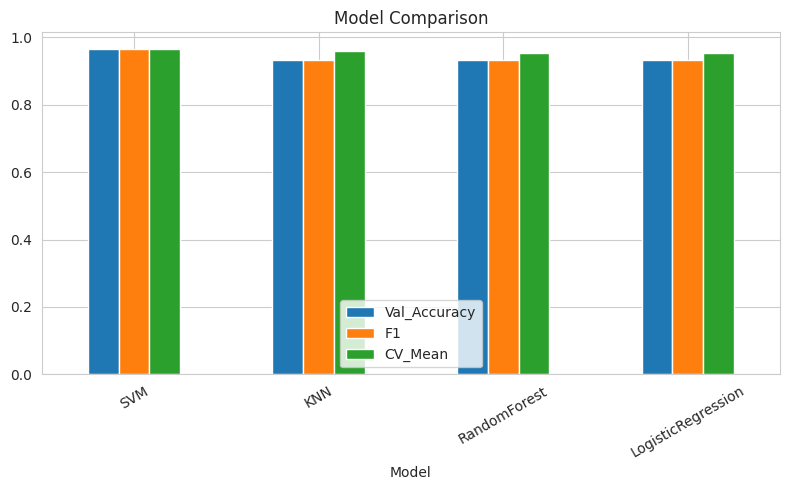

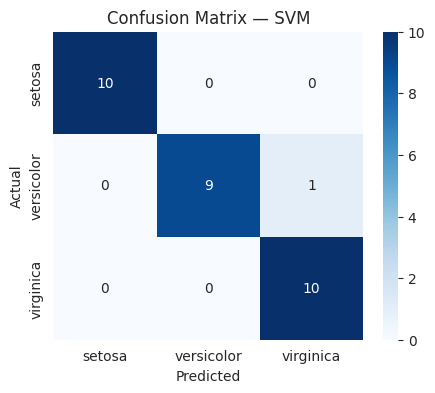

🏆 Best Model: SVM


In [3]:
# ============================================
# Module 3.1 — Train / Validation Split
# ============================================
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print("Train:", X_train.shape, "Val:", X_val.shape)

# ============================================
# Module 3.2 — Define 3 Models (Baseline + 2 Advanced)
# ============================================
models = {
    "LogisticRegression": LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM":                SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(n_neighbors=5),
}

# ============================================
# Module 3.3 / 3.4 — Train + Evaluate
# ============================================
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average="weighted")
    cv  = cross_val_score(model, X_scaled, y_enc, cv=5).mean()
    results.append({"Model": name, "Val_Accuracy": acc, "F1": f1, "CV_Mean": cv})
    trained_models[name] = model
    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | CV: {cv:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_))

# ============================================
# Module 3.5 — Model Comparison
# ============================================
res_df = pd.DataFrame(results).sort_values("CV_Mean", ascending=False).reset_index(drop=True)
print("\n===== Model Comparison =====")
display(res_df)

res_df.set_index("Model")[["Val_Accuracy","F1","CV_Mean"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

# Confusion Matrix of best model
best_name = res_df.iloc[0]["Model"]
best_model = trained_models[best_name]
cm = confusion_matrix(y_val, best_model.predict(X_val))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()
print("🏆 Best Model:", best_name)

## Module 5 — Final Model & Save Pickle

In [4]:
# ============================================
# Module 5.1 — Compare (already done above)
# ============================================
print(res_df)

# ============================================
# Module 5.2 — Train Final Model on FULL data (best one)
# ============================================
best_estimator = trained_models[best_name]
best_estimator.fit(X_scaled, y_enc)   # retrain on 100% data

# ============================================
# Module 5.3 / 5.4 / 5.5 — Save Pickle Bundle
# ============================================
bundle = {
    "model":    best_estimator,
    "scaler":   scaler,
    "encoder":  le,
    "features": X.columns.tolist(),
    "model_name": best_name,
    "accuracy": float(res_df.iloc[0]["Val_Accuracy"]),
}
os.makedirs("models", exist_ok=True)
with open("models/iris_best_model.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("✅ Saved → models/iris_best_model.pkl")

                Model  Val_Accuracy        F1   CV_Mean
0                 SVM      0.966667  0.966583  0.965977
1                 KNN      0.933333  0.932660  0.959080
2        RandomForest      0.933333  0.933333  0.952184
3  LogisticRegression      0.933333  0.933333  0.952184
✅ Saved → models/iris_best_model.pkl
